In [83]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [52]:
pwd

'/Users/bstanisl/Documents/repos/PVade/examples'

In [53]:
fname = '../output/empty2d/solution/solution_fluid.h5'

In [54]:
# Open the file (read-only)
with h5py.File(fname, "r") as f:
    # Explore the structure
    print("Top-level keys:", list(f.keys()))

    # print(f.visit(print))

    # Recursively print structure and types
    # def show_structure(name, obj):
    #     print(f"{name} -> {type(obj)}")

    # f.visititems(show_structure)

    # Access a dataset
    data = f["Function/velocity /0"][:]
    print(data.shape, data.dtype)

Top-level keys: ['Function', 'Mesh']
(77, 3) float64


In [55]:
with h5py.File(fname, "r") as f:
    # Mesh coordinates  ===============
    coords = f["Mesh/fluid_mesh.xdmf/geometry"][:]
    print("Coords shape:", coords.shape)  # Should be (538, 3) or (538, 2)

    # Velocity ===============
    velocity_group = f["Function/velocity "]

    # Sort dataset keys numerically
    keys = sorted(velocity_group.keys(), key=lambda k: float(k.replace("_", ".")))

    # Load all time steps into list
    data_list = [velocity_group[k][:] for k in keys]
    data_array = np.stack(data_list)  # Shape: (n_timesteps, n_points, 3)

    # Temperature ===============
    temp_group = f["Function/temperature "]

    # Sort dataset keys numerically
    keys2 = sorted(velocity_group.keys(), key=lambda k: float(k.replace("_", ".")))

    # Load all time steps into list
    data_list2 = [temp_group[k][:] for k in keys2]
    temp_data_array = np.stack(data_list2)  # Shape: (n_timesteps, n_points, 3)


print("Combined velocity shape:", data_array.shape)  # e.g. (100, 5000, 3)
print("Combined temperature shape:", temp_data_array.shape)  # e.g. (100, 5000, 3)

Coords shape: (77, 2)
Combined velocity shape: (1001, 77, 3)
Combined temperature shape: (1001, 77, 1)


In [ ]:
# Interpolate to regular grid
alldata = {}

nt, npoints, ncomp = data_array.shape

nx = 60 # 240 #120
ny = 30 # 40 #20

# Create regular grid to interpolate onto
xi = np.linspace(coords[:, 0].min(), coords[:, 0].max(), nx)
yi = np.linspace(coords[:, 1].min(), coords[:, 1].max(), ny)
X, Y = np.meshgrid(xi, yi, indexing='ij')

alldata['u'] = np.empty((nt, nx, ny))
alldata['v'] = np.empty((nt, nx, ny))
alldata['T'] = np.empty((nt, nx, ny))

# Interpolate
for t in range(nt):
    alldata['u'][t, :, :] = griddata(coords, data_array[t, :, 0], (X, Y), method='linear')
    alldata['v'][t, :, :] = griddata(coords, data_array[t, :, 1], (X, Y), method='linear')
    alldata['T'][t, :, :] = griddata(coords, temp_data_array[t, :, 0], (X, Y), method='linear')


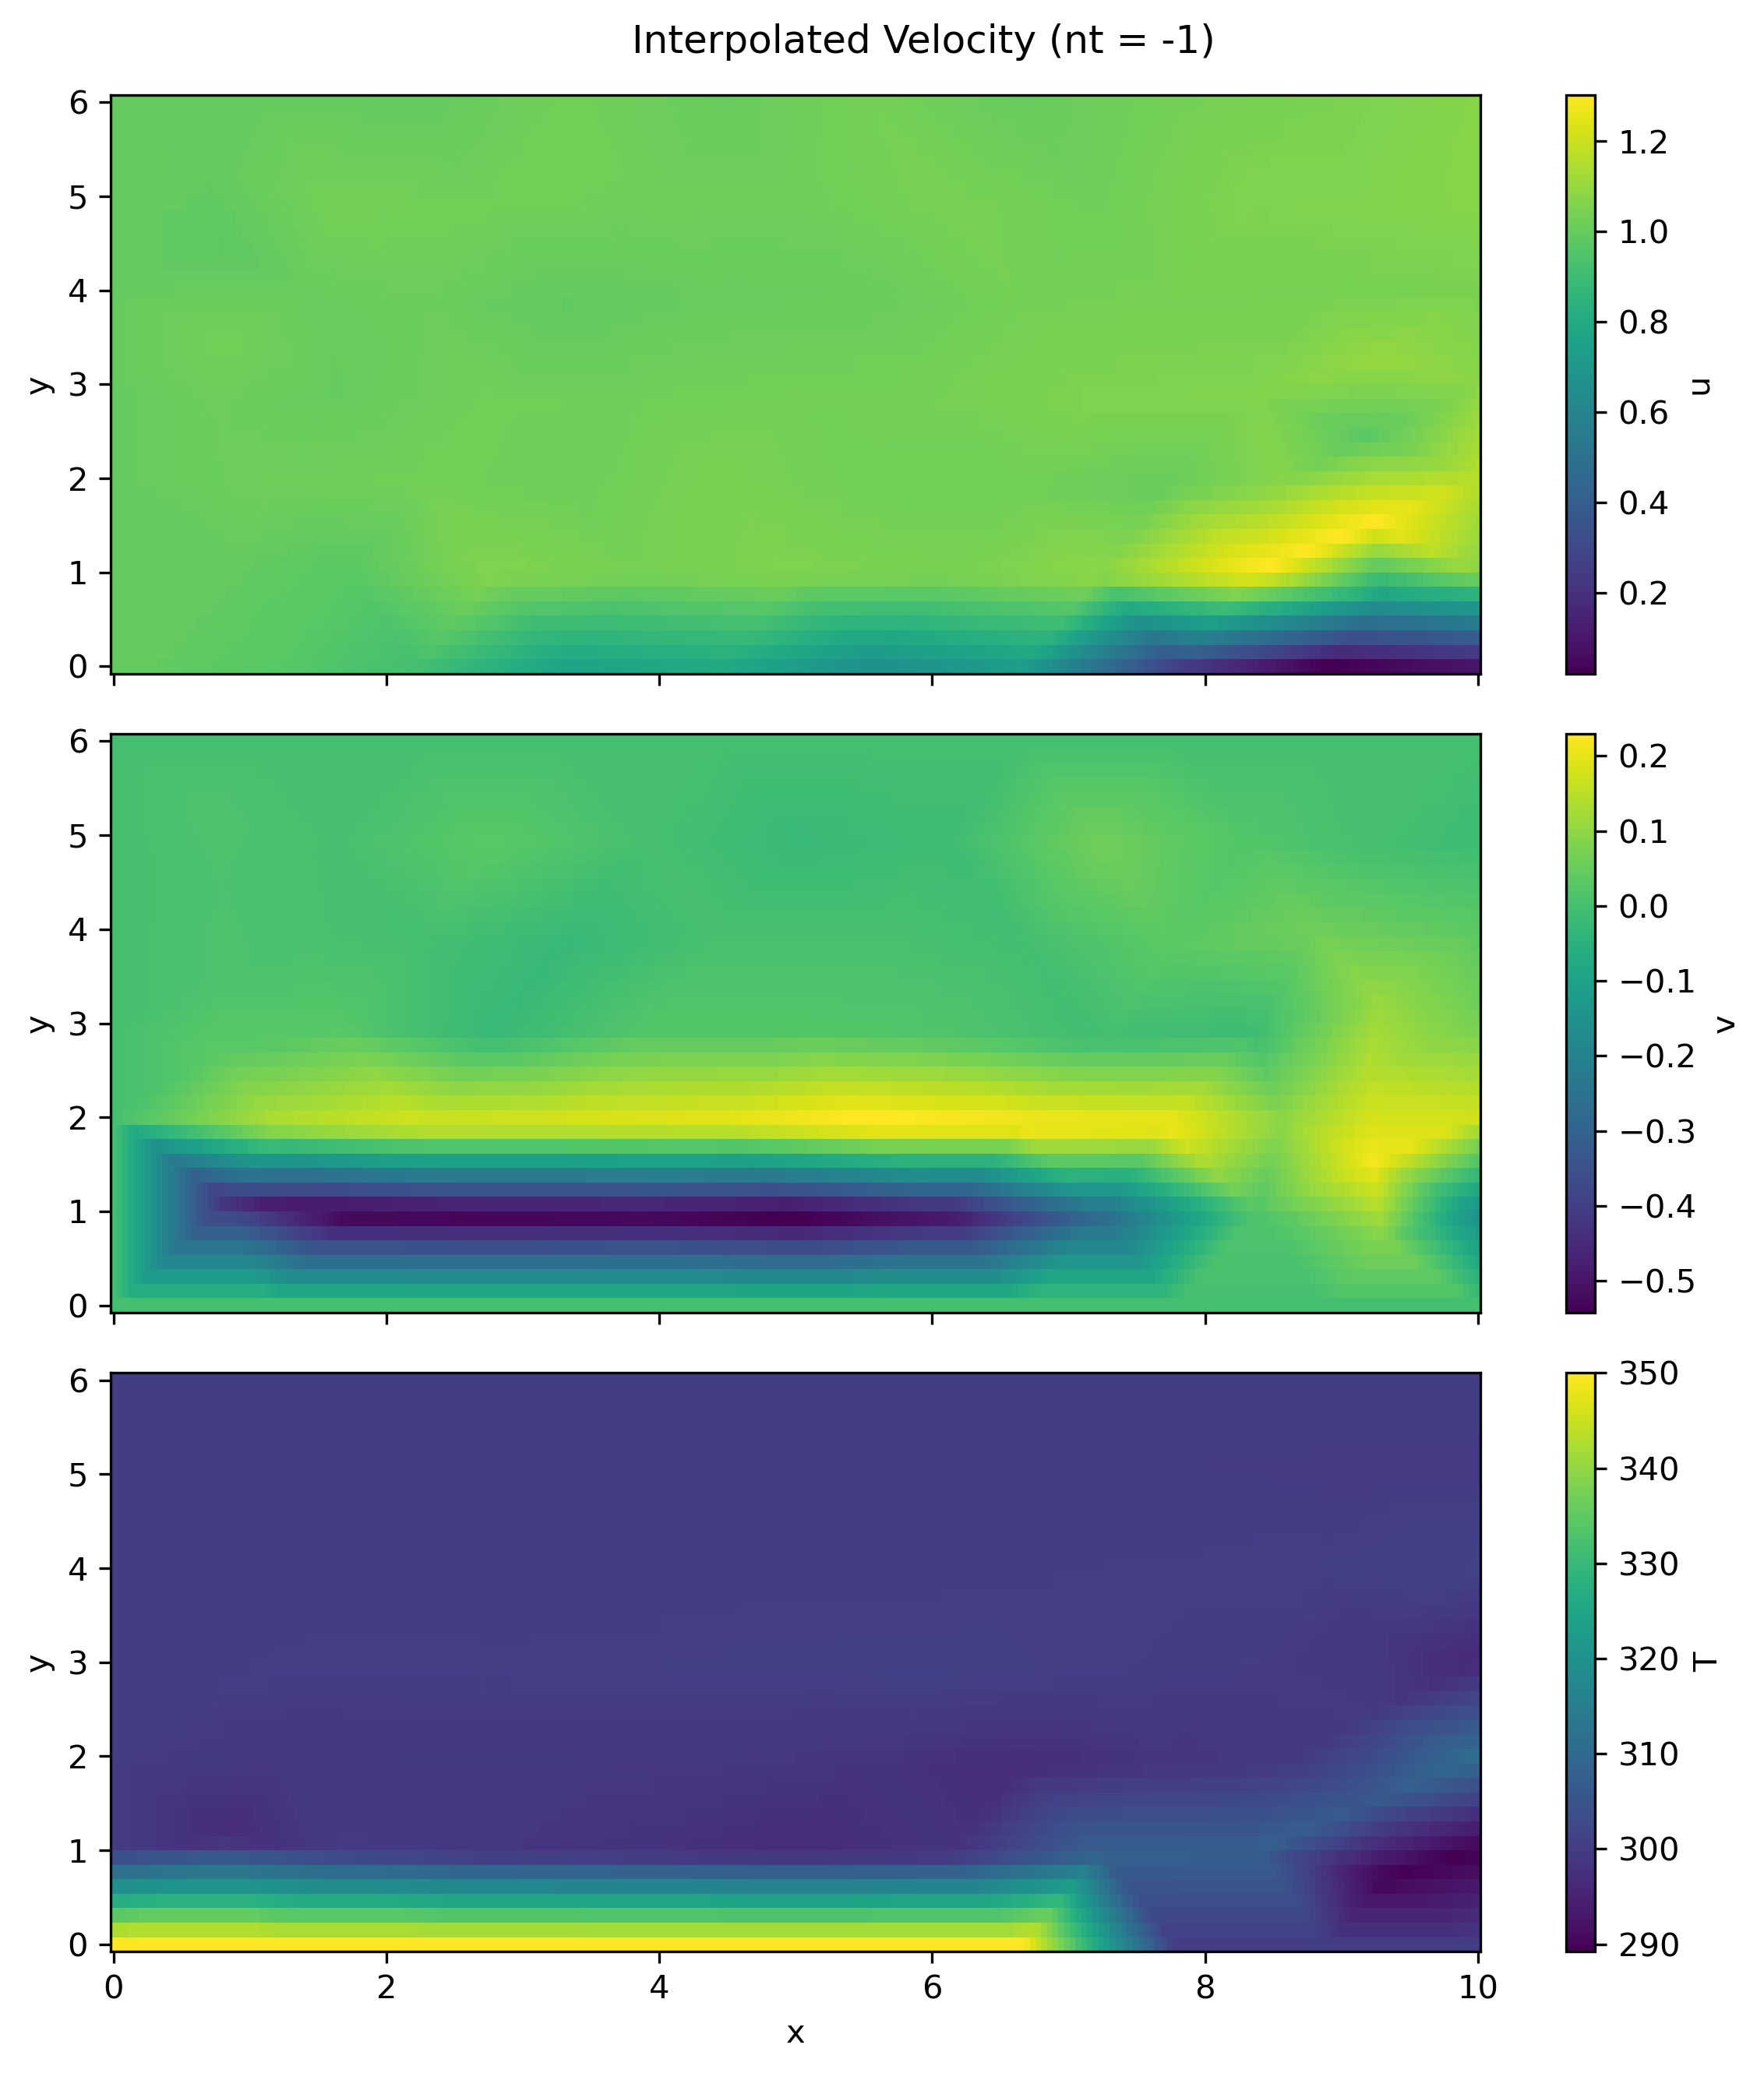

In [57]:
# Plot instantaneous fields with pcolormesh or imshow
t = -1 #200

# fig, axs = plt.subplots(2, 1, figsize=[8,6], sharex=True, dpi=300)
fig, axs = plt.subplots(3, 1, figsize=[8,9], sharex=True, dpi=300)

fig.suptitle("Interpolated Velocity (nt = {})".format(t))

for comp,ax in zip(alldata.keys(), axs.ravel()):
    pcm = ax.pcolormesh(X, Y, alldata[comp][t, :, :], shading='auto', cmap='viridis')
    plt.colorbar(pcm, ax=ax, label=comp)
    ax.set_ylabel("y")
axs[-1].set_xlabel("x")
plt.tight_layout()

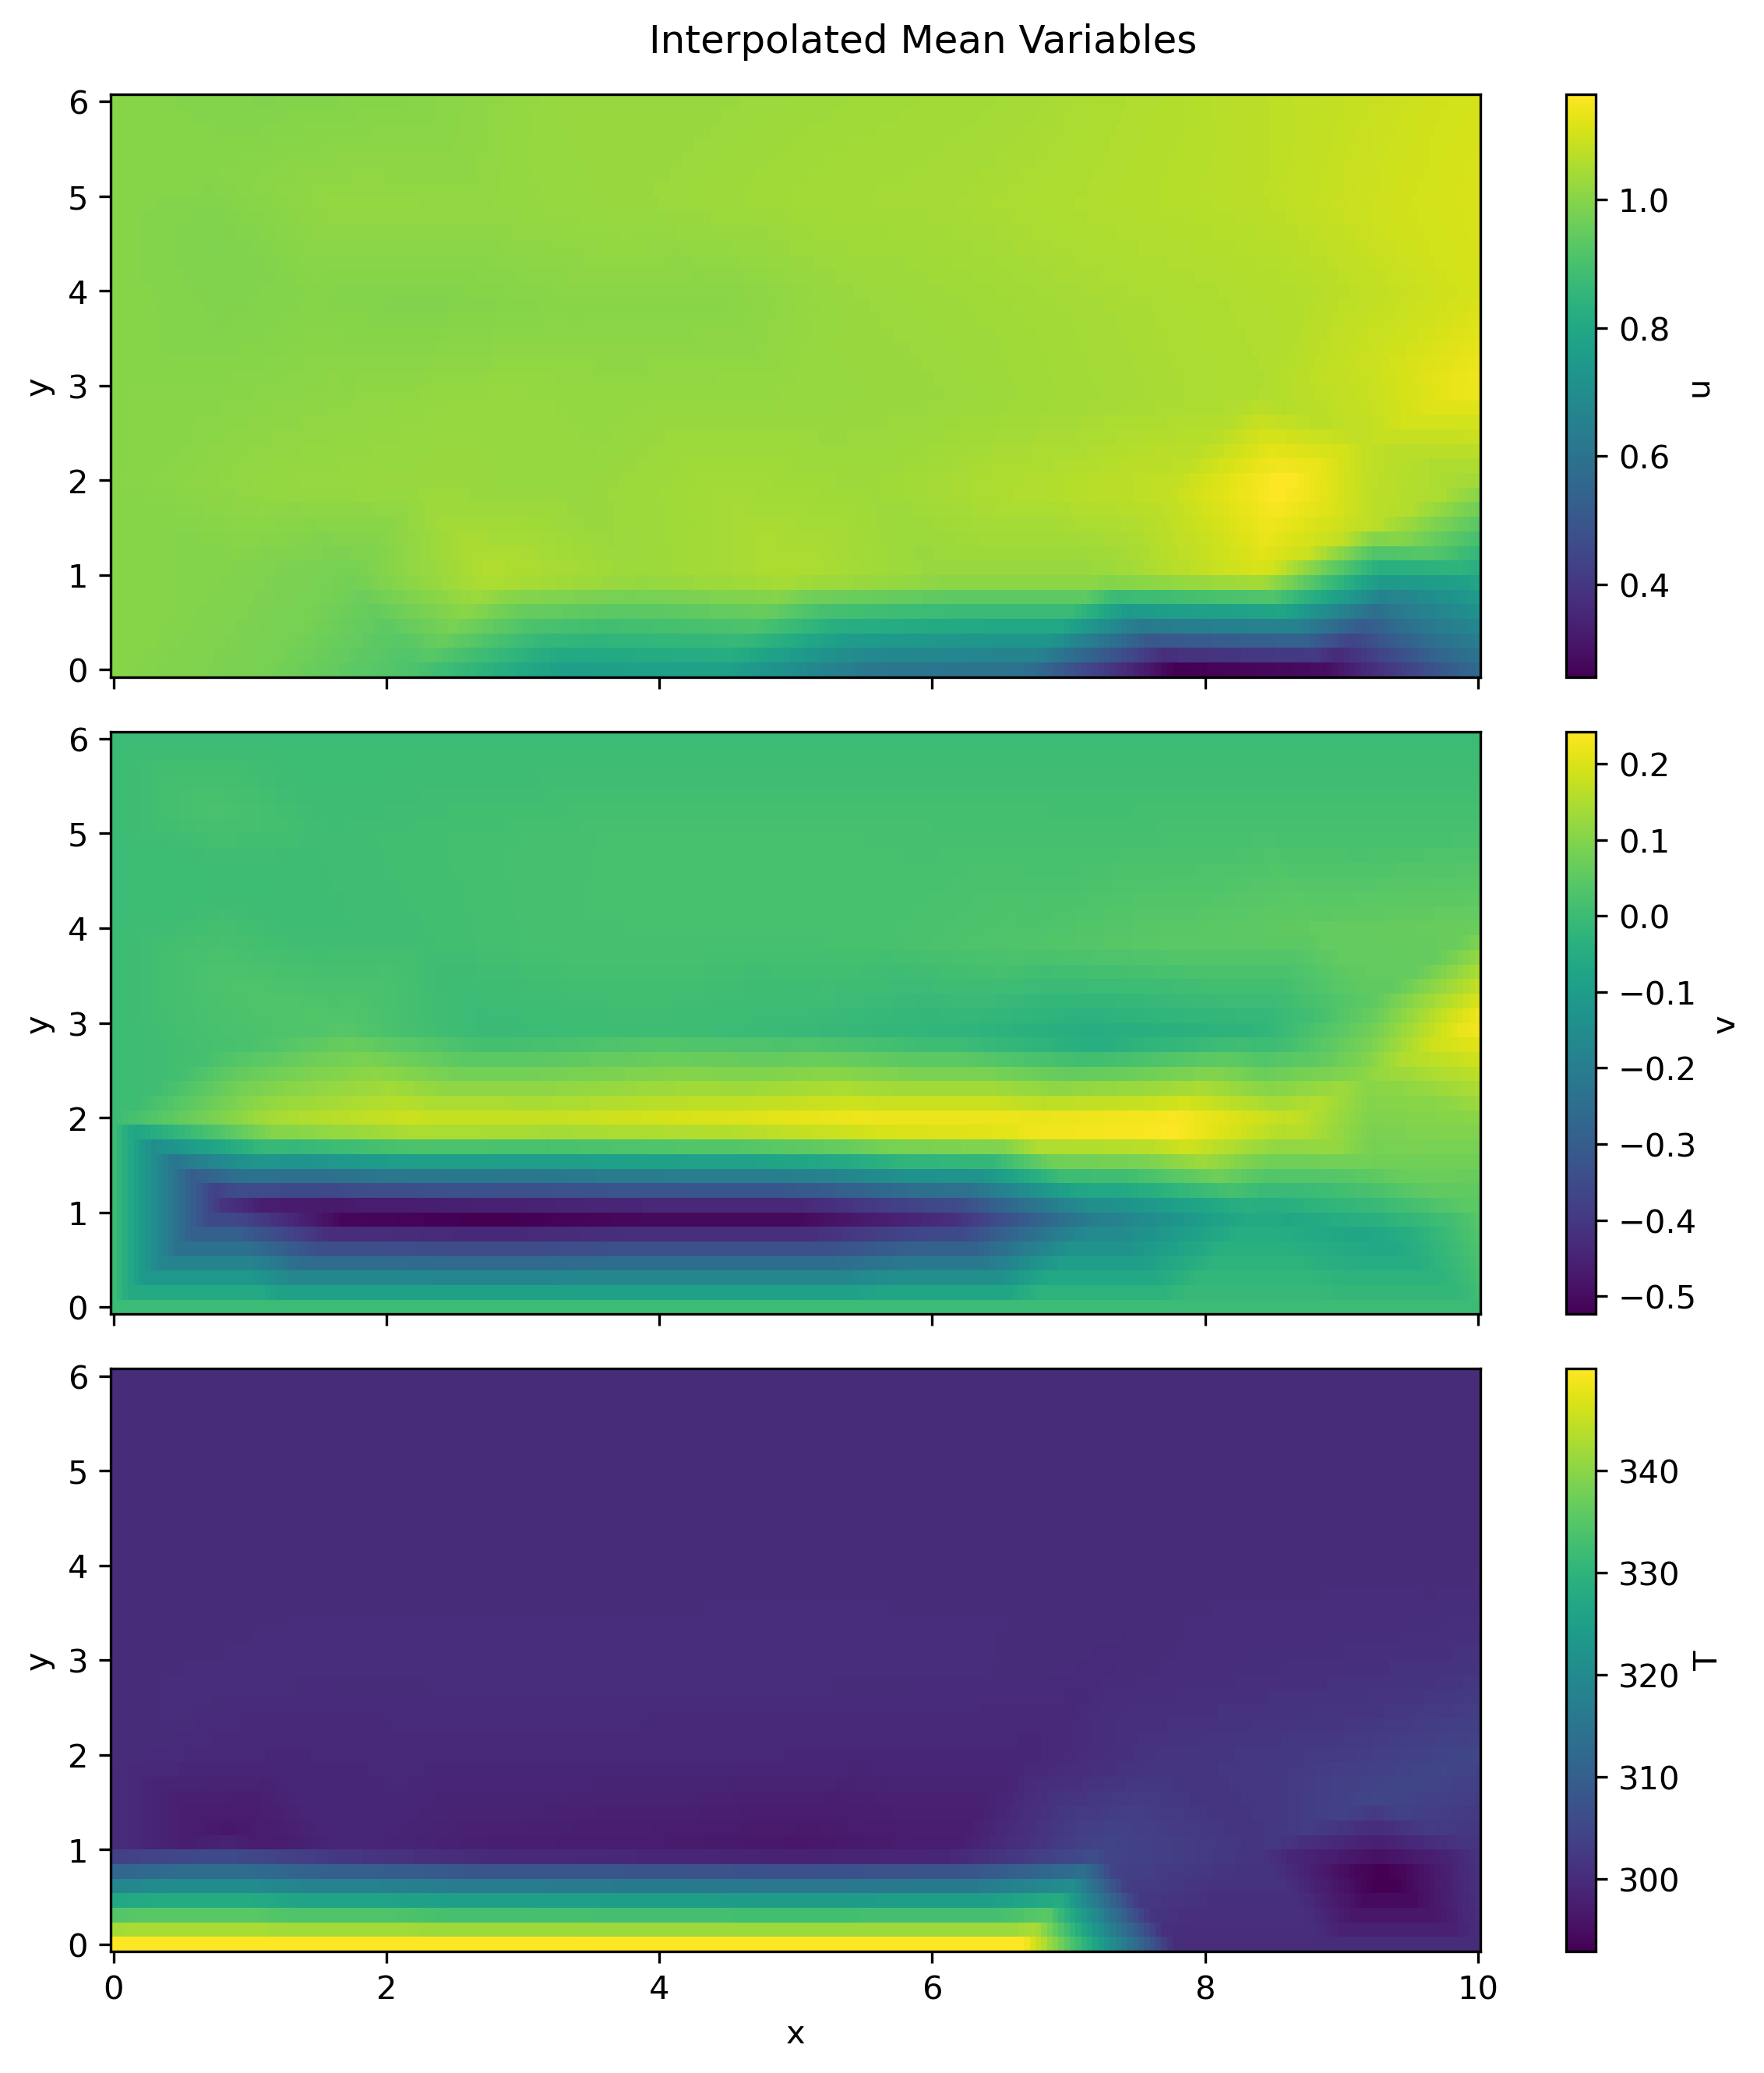

In [58]:
# Plot time-average fields with pcolormesh

fig, axs = plt.subplots(3, 1, figsize=[8,9], sharex=True, dpi=300)

fig.suptitle("Interpolated Mean Variables")

for comp,ax in zip(alldata.keys(), axs.ravel()):
    pcm = ax.pcolormesh(X, Y, np.average(alldata[comp], axis=0), shading='auto', cmap='viridis')
    plt.colorbar(pcm, ax=ax, label=comp)
    ax.set_ylabel("y")
axs[-1].set_xlabel("x")
plt.tight_layout()

In [59]:
# input params
u_inf = 1.0
L = xi[-1]
T_s = 350
T_inf = 300

dt = 0.02 # s
t_final = nt*dt
t_final

20.02

x_c = 6.652720 m


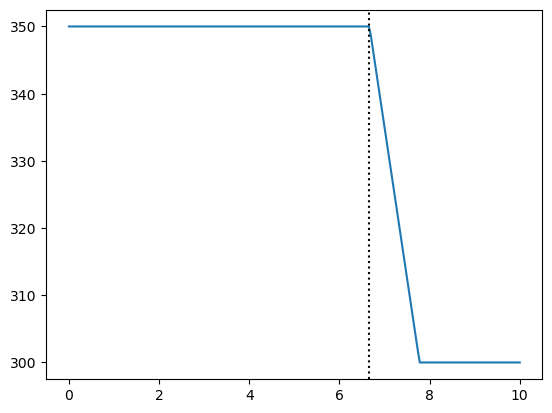

In [60]:
# determine x-section for analysis
T0_lower_wall = alldata['T'][1, :, 0]
T_threshold = T_s - 0.5 # there are some small errors
x_index_max = np.argmax(T0_lower_wall < T_threshold) - 1
x_critical = xi[x_index_max] if np.any(T0_lower_wall < T_threshold) else None
print('x_c = {:2f} m'.format(x_critical))

fig, axs = plt.subplots()
axs.plot(xi, T0_lower_wall)
axs.axvline(x_critical, color='k', linestyle=':')

In [61]:
def extract_subdomain(data, x_idx_max):
    newdata = {}
    for comp in data.keys():
        newdata[comp] = data[comp][:,0:x_idx_max,:]
    return newdata

In [62]:
data = extract_subdomain(alldata, x_index_max)

In [65]:
# compute mean profiles
meanprof = {}
for comp in data.keys():
    meanprof[comp] = np.average(np.average(data[comp],axis=0),axis=0)

In [ ]:
# def compute_BL_height(u, y):
#     u_inf_sim = 0.99*(u[-1])
#     delta_u_idx = np.argmax(u > u_inf_sim)
#     delta = y[delta_u_idx]

#     return delta

In [80]:
T_inf_sim

302.9956006696759

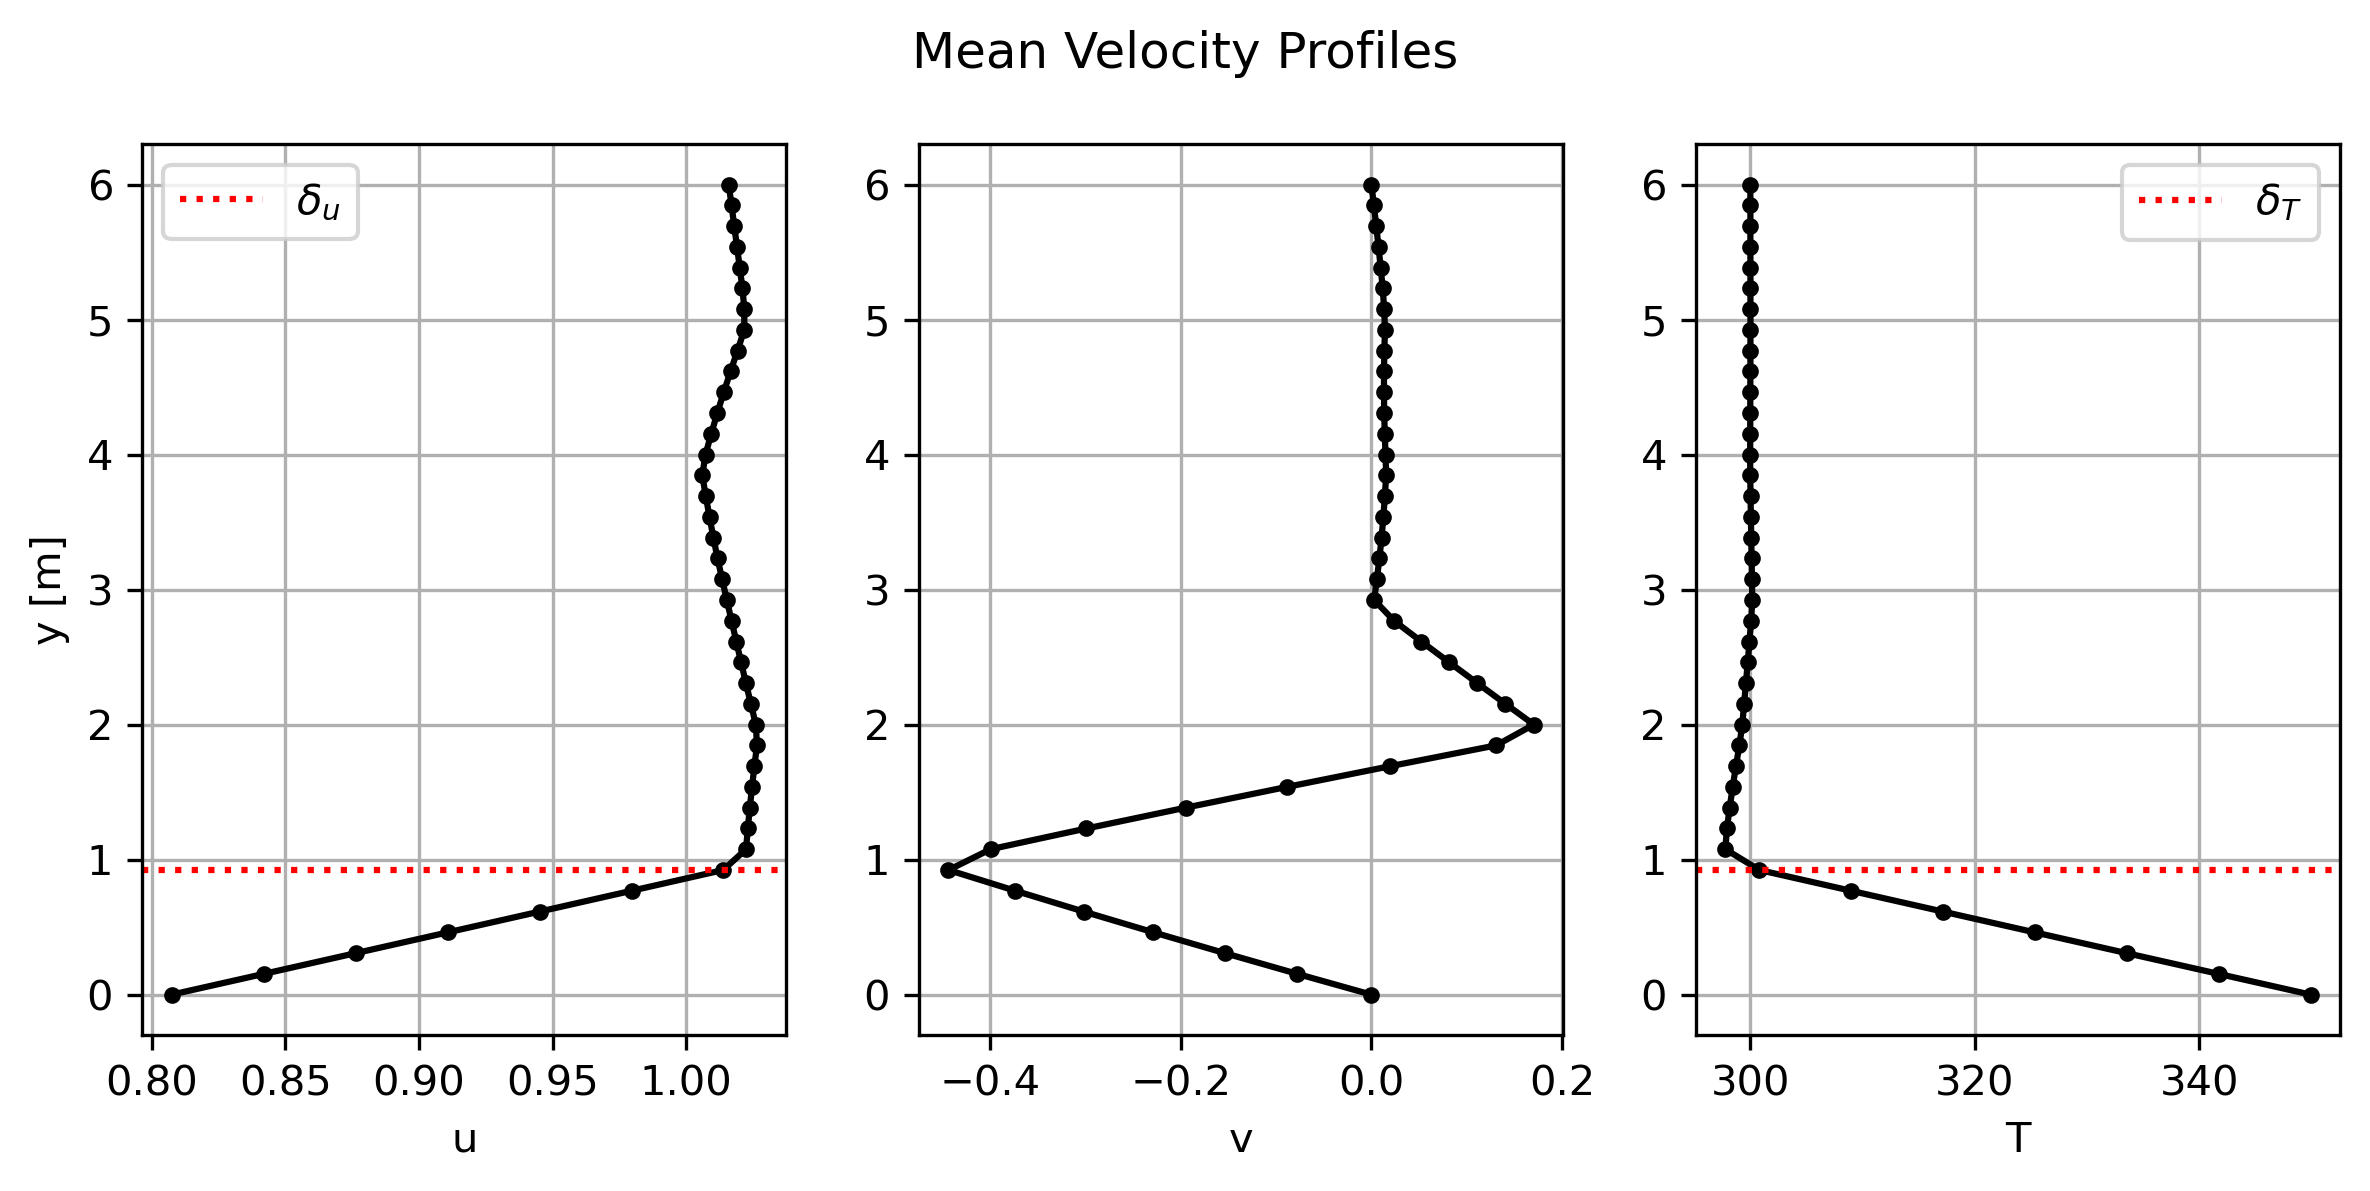

In [79]:
# plot vertical profiles

# calculate boundary layer heights
# delta_u_mean = compute_BL_height(meanprof['u'], yi)
# delta_T_mean = compute_BL_height(meanprof['T'], yi)
u_inf_sim = 0.99*(meanprof['u'][-1])
delta_u_idx = np.argmax(meanprof['u'] > u_inf_sim)
delta_u_mean = yi[delta_u_idx]

T_inf_sim = 1.01*(meanprof['T'][-1])
delta_T_idx = np.argmax(meanprof['T'] < T_inf_sim)
delta_T_mean = yi[delta_T_idx]

pltdata = meanprof

fig, axs = plt.subplots(1, 3, figsize=[8,4], dpi=300)

fig.suptitle("Mean Velocity Profiles")

for comp,ax in zip(pltdata.keys(), axs.ravel()):
    ax.plot(pltdata[comp], yi, 'k.-')
    if comp == 'u':
        ax.axhline(delta_u_mean, color='r', linestyle=':', label = '$\delta_u$')
        ax.legend()
    elif comp == 'T':
        ax.axhline(delta_T_mean, color='r', linestyle=':', label = '$\delta_T$')
        ax.legend()
    ax.set_xlabel("{}".format(comp))
    ax.grid()
axs[0].set_ylabel("y [m]")
plt.tight_layout()

In [85]:
# compare to literature
# Incropera solution to Laminar Flow over Isothermal Flat Plate
# Fig 7.4

# from table printed in text book
values = np.array([
    [0.0, 0.0,   0.0,   0.332],
    [0.4, 0.027, 0.133, 0.331],
    [0.8, 0.106, 0.265, 0.327],
    [1.2, 0.238, 0.394, 0.317],
    [1.6, 0.420, 0.517, 0.297],
    [2.0, 0.650, 0.630, 0.267],
    [2.4, 0.922, 0.729, 0.228],
    [2.8, 1.231, 0.812, 0.184],
    [3.2, 1.569, 0.876, 0.139],
    [3.6, 1.930, 0.923, 0.098],
    [4.0, 2.306, 0.956, 0.064],
    [4.4, 2.692, 0.976, 0.039],
    [4.8, 3.085, 0.988, 0.022],
    [5.2, 3.482, 0.994, 0.011],
    [5.6, 3.880, 0.997, 0.005],
    [6.0, 4.280, 0.999, 0.002],
    [6.4, 4.679, 1.000, 0.001],
    [6.8, 5.079, 1.000, 0.000]
])

# from webplotdigitizer
temp_values = pd.read_csv('wpd_datasets.csv')

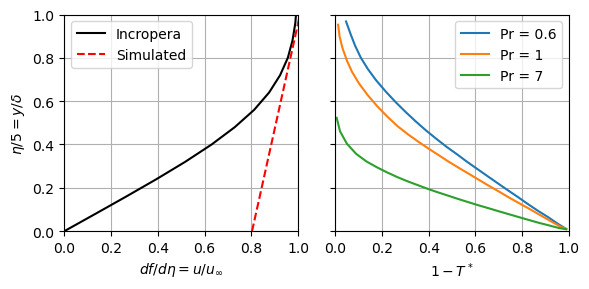

In [90]:
# compare to literature

# dimensionless temperature
Tstar = (meanprof['T'] - T_s) / (T_inf_sim - T_s) # Eq 6.33

# Incropera solution to Laminar Flow over Isothermal Flat Plate
# Fig 7.4
eta = values[:,0]
u_u_inf = values[:,2]

fig, axs = plt.subplots(1,2,figsize=[6,3],sharey=True)
axs[0].plot(u_u_inf, eta/5.0, 'k', label = 'Incropera')
axs[0].plot(meanprof['u']/u_inf_sim, yi/delta_u_mean, 'r--', label = 'Simulated')
axs[0].set_ylabel('$\eta / 5 = y / \delta$')
axs[0].set_xlabel('$df/d\eta = u/u_{\infty}$')
axs[0].legend()

axs[1].plot(temp_values['X_Pr0_6'],temp_values['Pr0_6'], label='Pr = 0.6')
axs[1].plot(temp_values['X_Pr1'],temp_values['Pr1'], label='Pr = 1')
axs[1].plot(temp_values['X_Pr7'],temp_values['Pr7'], label='Pr = 7')
axs[1].legend()
axs[1].set_xlabel('$1 - T^*$')

for ax in axs:
    ax.set_ylim([0,1])
    ax.set_xlim([0,1])
    ax.grid()

plt.tight_layout()

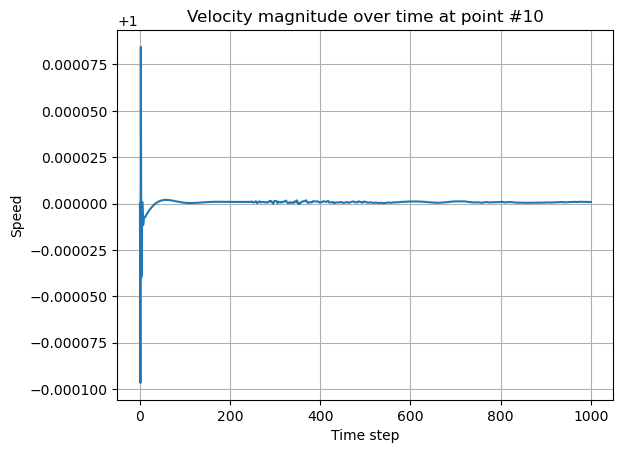

In [ ]:
# Compute speed (vector magnitude) at point 100 across time
point_index = 10
speed = np.linalg.norm(data_array[:, point_index, :], axis=1)

plt.plot(speed)
plt.title(f"Velocity magnitude over time at point #{point_index}")
plt.xlabel("Time step")
plt.ylabel("Speed")
plt.grid(True)
plt.show()

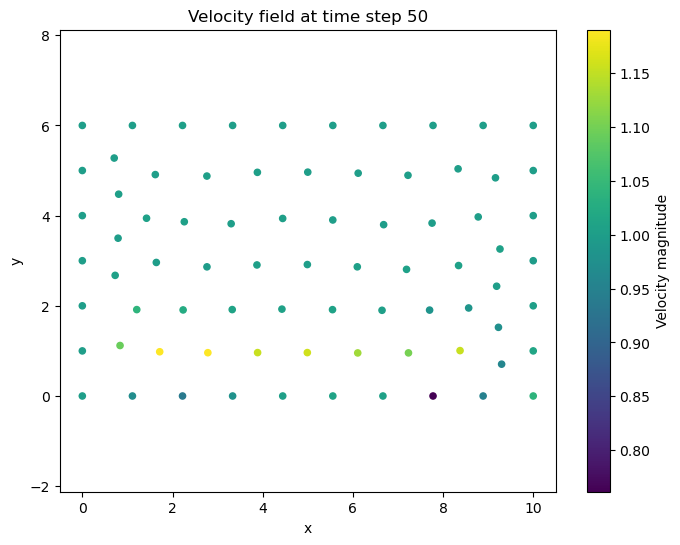

In [ ]:
# Use a time step
t = 50
v = data_array[t]
speed = np.linalg.norm(v, axis=1)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=speed, cmap="viridis", s=20)
# plt.scatter(coords[:, 0], coords[:, 1], c=v[:,0], cmap="viridis", s=20)
plt.colorbar(label="Velocity magnitude")
plt.title(f"Velocity field at time step {t}")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()